# SARD Dataset Exploration

This notebook explores the Search and Rescue (SARD) dataset, which contains aerial imagery for human detection.

## Setup

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import yaml

DATA_DIR = '../data/search-and-rescue'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VALID_DIR = os.path.join(DATA_DIR, 'valid')
TEST_DIR = os.path.join(DATA_DIR, 'test')

with open(os.path.join(DATA_DIR, 'data.yaml'), 'r') as f:
    data_config = yaml.safe_load(f)

classes = data_config['names']
print(f"Classes: {classes}")

Classes: ['human']


## Dataset Summary

In [2]:
def count_files(directory):
    images = glob.glob(os.path.join(directory, 'images', '*.jpg'))
    labels = glob.glob(os.path.join(directory, 'labels', '*.txt'))
    return len(images), len(labels)

splits = ['train', 'valid', 'test']
for split in splits:
    img_count, lbl_count = count_files(os.path.join(DATA_DIR, split))
    print(f"{split.capitalize()}: {img_count} images, {lbl_count} labels")

Train: 4041 images, 4041 labels
Valid: 1144 images, 1144 labels
Test: 570 images, 570 labels


## Bounding Box Analysis

In [3]:
def get_bbox_stats(directory):
    label_files = glob.glob(os.path.join(directory, 'labels', '*.txt'))
    all_bboxes = []
    boxes_per_image = []
    
    for label_file in label_files:
        with open(label_file, 'r') as f:
            lines = f.readlines()
            boxes_per_image.append(len(lines))
            for line in lines:
                # YOLO format: class x_center y_center width height
                parts = list(map(float, line.strip().split()))
                if len(parts) == 5:
                    all_bboxes.append(parts[1:])
    
    return np.array(all_bboxes), boxes_per_image

train_bboxes, train_counts = get_bbox_stats(TRAIN_DIR)

print(f"Total bounding boxes in train: {len(train_bboxes)}")
print(f"Average boxes per image: {np.mean(train_counts):.2f}")
print(f"Max boxes in one image: {np.max(train_counts)}")

Total bounding boxes in train: 5229
Average boxes per image: 1.29
Max boxes in one image: 7


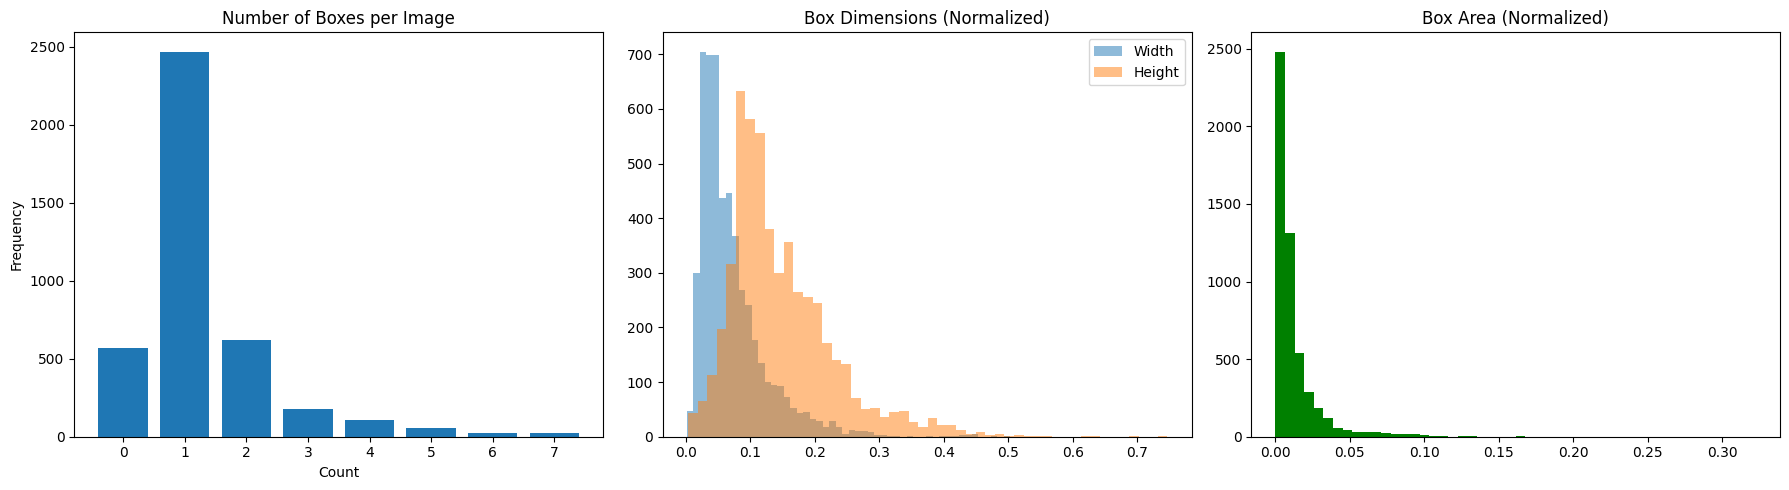

In [4]:
widths = train_bboxes[:, 2]
heights = train_bboxes[:, 3]
areas = widths * heights

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(train_counts, bins=range(max(train_counts)+2), align='left', rwidth=0.8)
axes[0].set_title('Number of Boxes per Image')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(widths, bins=50, alpha=0.5, label='Width')
axes[1].hist(heights, bins=50, alpha=0.5, label='Height')
axes[1].set_title('Box Dimensions (Normalized)')
axes[1].legend()

axes[2].hist(areas, bins=50, color='green')
axes[2].set_title('Box Area (Normalized)')

plt.tight_layout()
plt.show()

## Visualizations

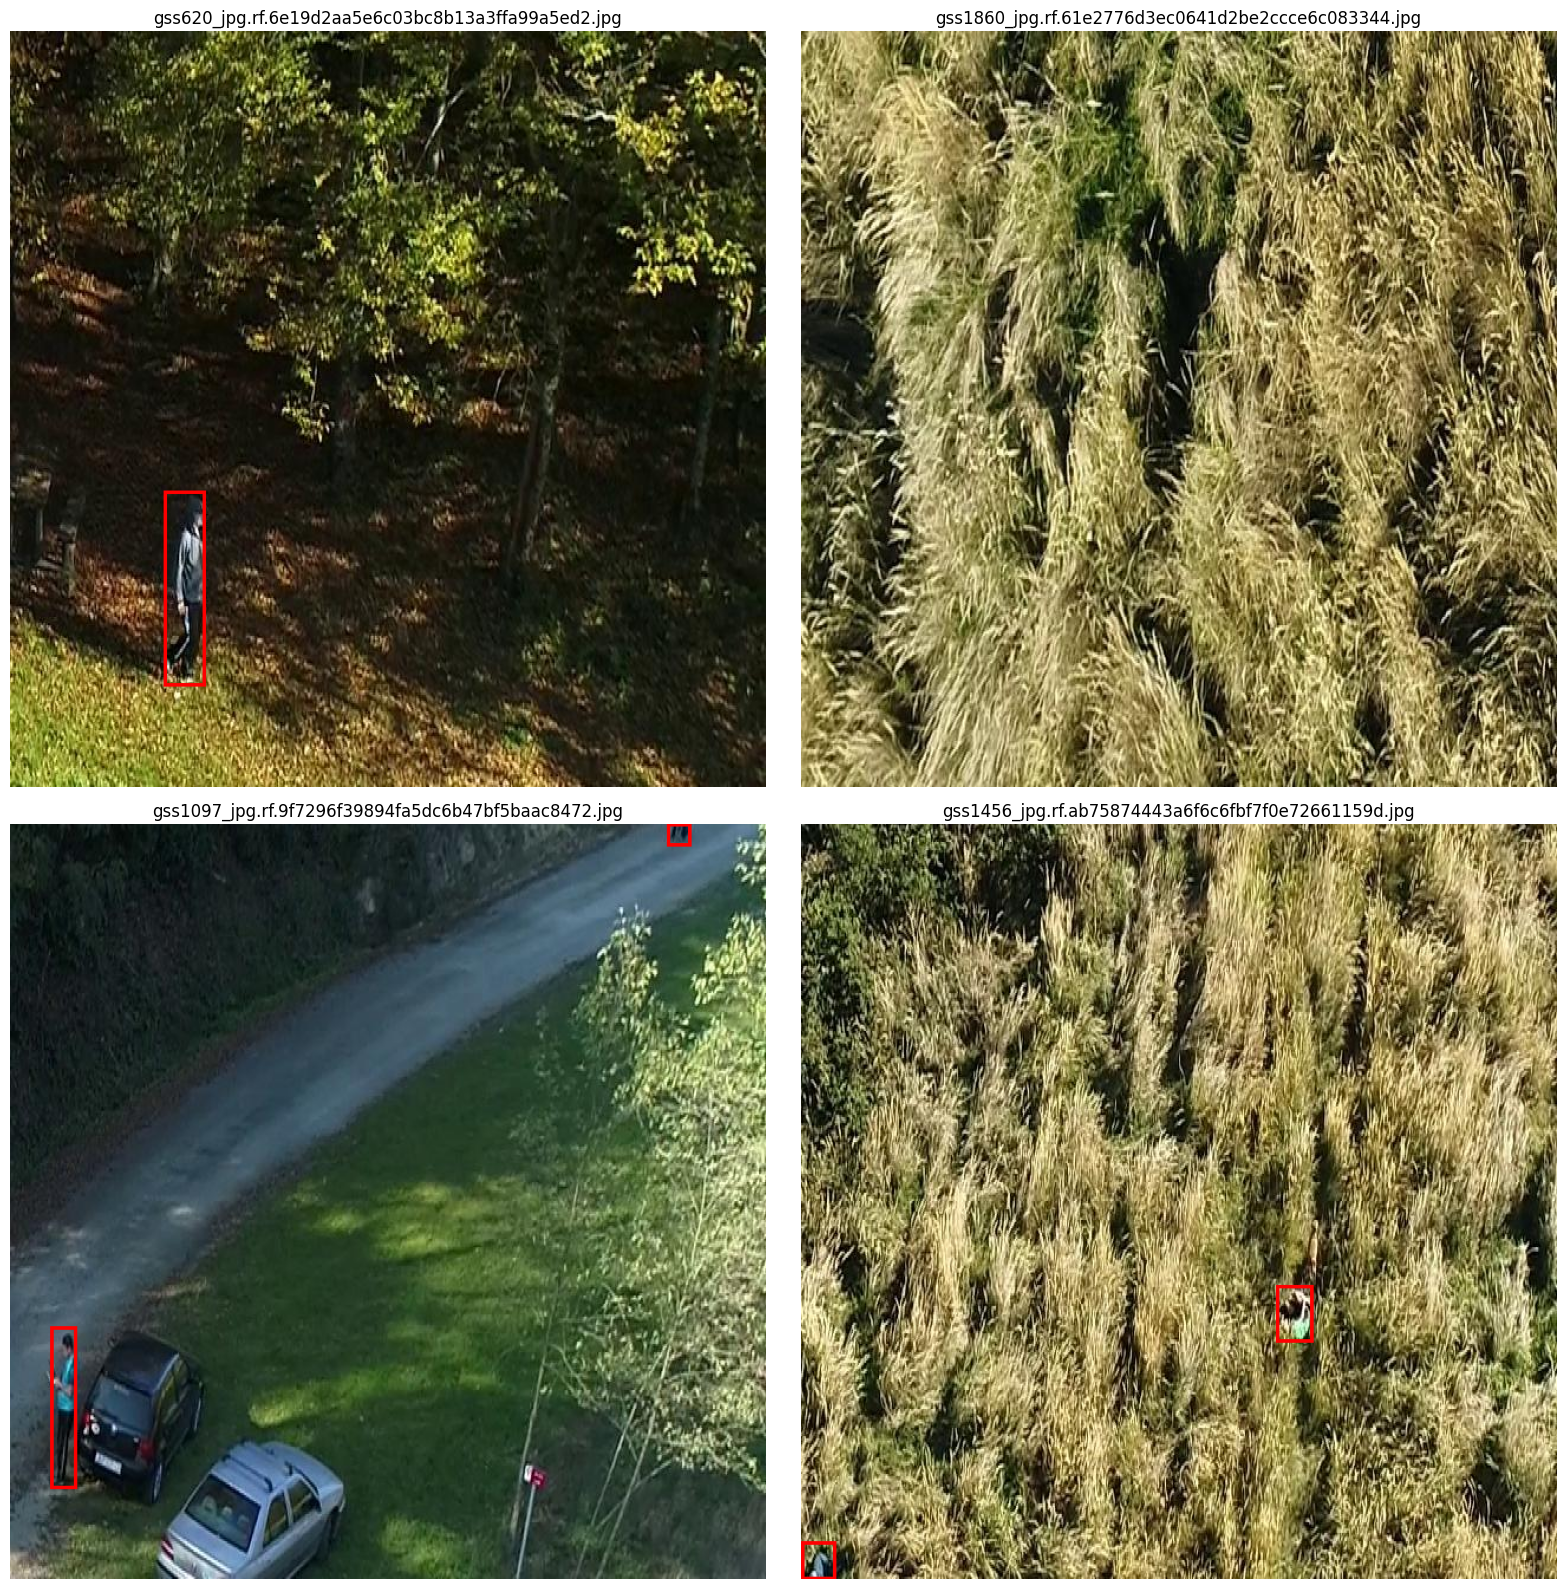

In [6]:
def draw_boxes(image_path, label_path):
    img = Image.open(image_path)
    draw = ImageDraw.Draw(img)
    w, h = img.size
    
    with open(label_path, 'r') as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            
            # Convert YOLO to pixel coordinates
            left = (x - bw/2) * w
            top = (y - bh/2) * h
            right = (x + bw/2) * w
            bottom = (y + bh/2) * h
            
            draw.rectangle([left, top, right, bottom], outline="red", width=3)
    
    return img

train_images = glob.glob(os.path.join(TRAIN_DIR, 'images', '*.jpg'))
np.random.seed(42)
sample_indices = np.random.choice(len(train_images), 4, replace=False)

plt.figure(figsize=(16, 16))
for i, idx in enumerate(sample_indices):
    img_path = train_images[idx]
    lbl_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
    
    img_with_boxes = draw_boxes(img_path, lbl_path)
    
    plt.subplot(2, 2, i+1)
    plt.imshow(img_with_boxes)
    plt.axis('off')
    plt.title(os.path.basename(img_path))

plt.tight_layout()
plt.show()